# Basic Yelp Dataset Exploration

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../yelp_Dataset/yelp_sentiments.csv')

# Read only a manageable number of rows for quick exploration.
df = pd.read_csv(DATA_PATH, nrows=100_000)
print(f'Sample shape: {df.shape}')
df.head()

Sample shape: (100000, 3)


,text,sentiment,text_len
0,I was glad that I was able to find a korean re...,2,289
1,Bloomsday is the quintessential Philly spot; F...,3,335
2,"What can I say.. It's Indian food, definitely...",2,176
3,The best!\n\nThe Bismarck is the best I have e...,3,265
4,Over all my experience would have been amazing...,2,1598


In [3]:
df.info()

print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_values'))

print(f'\nDuplicate rows in this sample: {df.duplicated().sum():,}')

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   text       100000 non-null  str  
 1   sentiment  100000 non-null  int64
 2   text_len   100000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 60.6 MB

Missing values:


,missing_values
text,0
sentiment,0
text_len,0



Duplicate rows in this sample: 0


,reviews
sentiment,
Negative,33494
Neutral,33037
Positive,33469


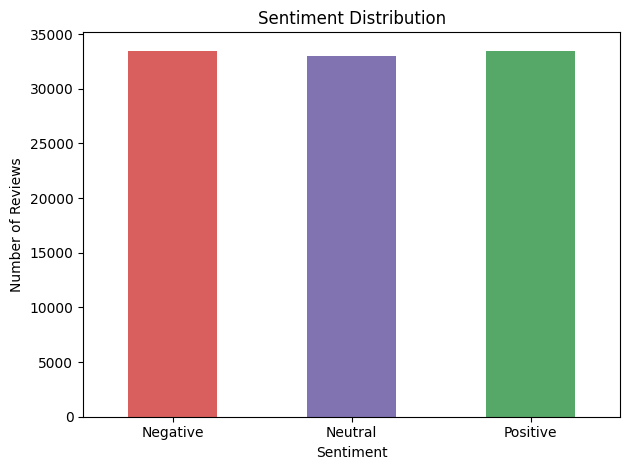

In [4]:
label_names = {1: 'Negative', 2: 'Neutral', 3: 'Positive'}
class_counts = df['sentiment'].value_counts().sort_index()
class_counts.index = class_counts.index.map(label_names)
display(class_counts.to_frame('reviews'))

ax = class_counts.plot(kind='bar', color=['#d95f5f', '#8172b2', '#55a868'], rot=0)
ax.set_title('Sentiment Distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [5]:
# text_len is character count. word_count is useful for the short-vs-long analysis later.
df['word_count'] = df['text'].fillna('').str.split().str.len()
length_summary = (
    df.groupby('sentiment')[['text_len', 'word_count']]
    .agg(['mean', 'median', 'min', 'max'])
)
length_summary.index = length_summary.index.map(label_names)
display(length_summary)

text_len                   word_count                 
                 mean median min   max        mean median min   max
sentiment                                                          
Negative   674.392757  492.0   8  5000  126.022452   92.0   1  1005
Neutral    662.526107  503.0  10  4999  122.858885   93.0   2   953
Positive   497.271176  351.0   7  5000   90.792256   64.0   1   924

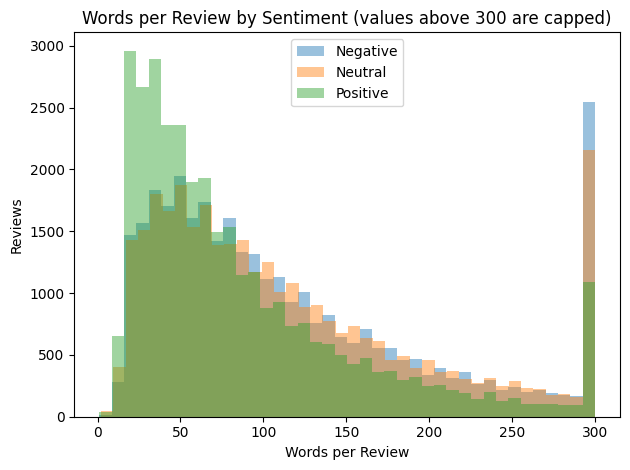

In [6]:
for label, name in label_names.items():
    plt.hist(
        df.loc[df['sentiment'] == label, 'word_count'].clip(upper=300),
        bins=40, alpha=0.45, label=name
    )

plt.title('Words per Review by Sentiment (values above 300 are capped)')
plt.xlabel('Words per Review')
plt.ylabel('Reviews')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
for label, name in label_names.items():
    print(f'\n{name} examples:')
    display(
        df.loc[df['sentiment'] == label, ['text', 'text_len', 'word_count']]
        .sample(3, random_state=42)
    )


Negative examples:


,text,text_len,word_count
71554,Decided to check this place out after our tour...,492,93
91309,The magic was good around the table. The show...,455,94
55349,"OK, I normally don't do this but I think I jus...",549,105



Neutral examples:


,text,text_len,word_count
82121,"The restaurant is beautiful, but the menu is l...",709,134
28681,Out of curiosity I wanted to see what this pla...,444,83
19609,"For an older, renovated beach hotel/resort, yo...",2490,452



Positive examples:


,text,text_len,word_count
65988,Went here while staying at the W - prolly woul...,883,166
37639,"While shopping at Cool Springs, I worked up an...",966,167
26220,Great place for football Sundays. They had the...,275,49


# Create Train, Validation, and Test Splits

In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = Path('yelp_sentiments.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('/home/ubuntu/upload/yelp_sentiments.csv')

SAMPLES_PER_CLASS = 10_000  # Set this to 1_000 for a quick test.
RANDOM_STATE = 42
CHUNK_SIZE = 100_000
LABEL_MAP = {1: 0, 2: 1, 3: 2}

OUTPUT_DIR = Path('splits')
OUTPUT_DIR.mkdir(exist_ok=True)

In [ ]:
# Collect the same number of reviews from each sentiment class without loading the full CSV.
samples = {1: [], 2: [], 3: []}
collected = {1: 0, 2: 0, 3: 0}

for chunk_number, chunk in enumerate(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE), start=1):
    for sentiment in samples:
        remaining = SAMPLES_PER_CLASS - collected[sentiment]
        if remaining <= 0:
            continue

        group = chunk.loc[chunk['sentiment'] == sentiment]
        take = min(remaining, len(group))
        if take > 0:
            samples[sentiment].append(
                group.sample(n=take, random_state=RANDOM_STATE + chunk_number + sentiment)
            )
            collected[sentiment] += take

    if all(value == SAMPLES_PER_CLASS for value in collected.values()):
        break

print('Collected rows per class:', collected)
if not all(value == SAMPLES_PER_CLASS for value in collected.values()):
    raise ValueError('The CSV did not contain enough rows for one or more classes.')

df = pd.concat([pd.concat(samples[label]) for label in sorted(samples)], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df['label'] = df['sentiment'].map(LABEL_MAP)

display(df['sentiment'].value_counts().sort_index().to_frame('reviews'))
df.head()

In [ ]:
# First split: 80% train and 20% temporary.
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label'],
    random_state=RANDOM_STATE,
)

# Second split: divide the temporary set into 10% validation and 10% test.
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=RANDOM_STATE,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

In [ ]:
train_df.to_csv(OUTPUT_DIR / 'train.csv', index=False)
val_df.to_csv(OUTPUT_DIR / 'val.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test.csv', index=False)

summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
})
display(summary)

for name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    print(f'\n{name.capitalize()} class counts:')
    display(split_df['sentiment'].value_counts().sort_index().to_frame('reviews'))